In [2]:
import pandas as pd

# Skip top rows
df = pd.read_csv("world_population.csv", skiprows=4)

# Show data
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0


In [9]:
# Rename column
df = df.rename(columns={"Country Name": "Country"})

# Keep only population data
df = df[df["Indicator Name"] == "Population, total"]

# Remove empty rows
df = df.dropna(subset=["Country"])

# Keep valid country codes
df = df[df["Country Code"].str.len() == 3]

# Remove unwanted groups BEFORE sorting
df = df[~df["Country"].str.contains("Fragile|North America|Euro|income|IDA|OECD|dividend|countries|World", case=False)]

# Get latest year
latest_year = df.columns[-1]

# Select needed data
data = df[["Country", latest_year]]

# Top 10 countries
top10 = data.sort_values(by=latest_year, ascending=False).head(10)

top10

,Country,2024
109,India,1.450936e+09
40,China,1.408975e+09
251,United States,3.401110e+08
106,Indonesia,2.834879e+08
184,Pakistan,2.512692e+08
174,Nigeria,2.326795e+08
29,Brazil,2.119986e+08
20,Bangladesh,1.735624e+08
202,Russian Federation,1.435339e+08
72,Ethiopia,1.320598e+08


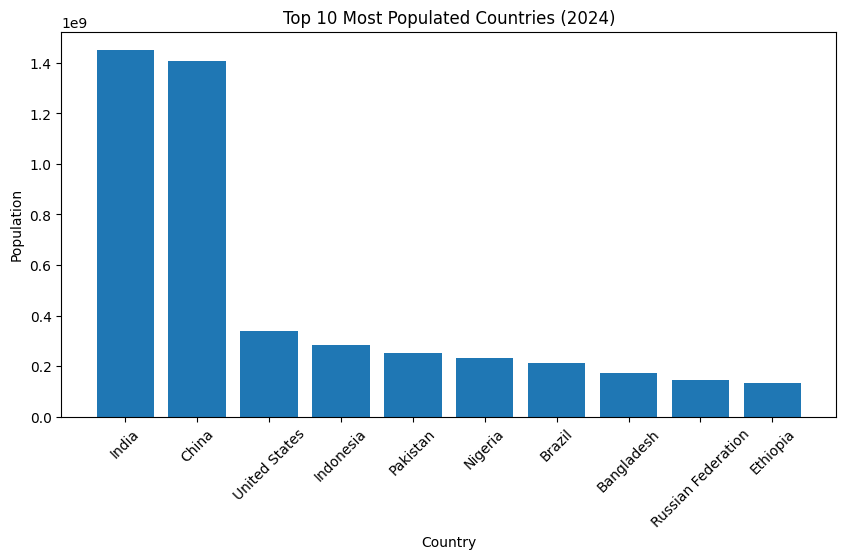

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top10["Country"], top10[latest_year])

plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Population")
plt.title("Top 10 Most Populated Countries (2024)")

plt.show()

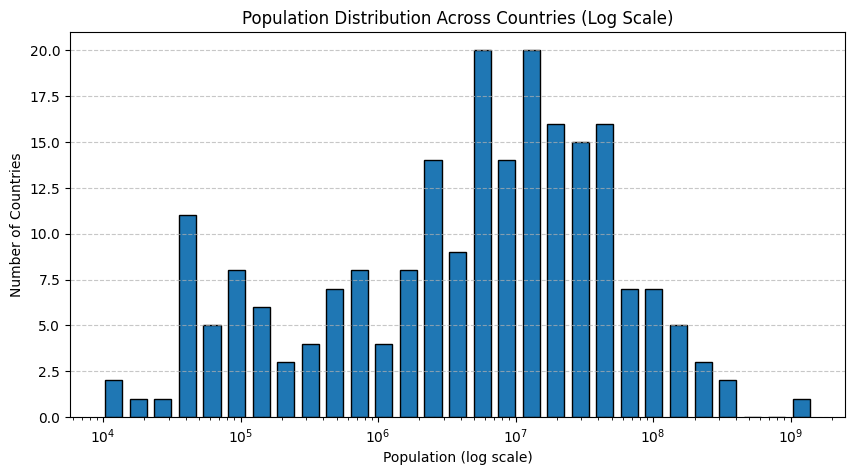

In [18]:
import matplotlib.pyplot as plt
import numpy as np

pop_data = data[latest_year].dropna()
pop_data = pop_data[pop_data > 0]

plt.figure(figsize=(10,5))

bins = np.logspace(np.log10(pop_data.min()), np.log10(pop_data.max()), 30)

plt.hist(pop_data, bins=bins, rwidth=0.7, edgecolor='black')

plt.xscale('log')

plt.xlabel("Population (log scale)")
plt.ylabel("Number of Countries")
plt.title("Population Distribution Across Countries (Log Scale)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()